# ERA5 Boundary Layer Height (BLH) — Data Crawling

Download ERA5 BLH for 6 Hanoi PM2.5 stations and merge into `daily_merged.csv`.

**Variables downloaded:**
- `boundary_layer_height` — chiều cao tầng biên khí quyển (m)

**Output features:**
- `blh_mean` — trung bình 24h
- `blh_min` — giá trị nhỏ nhất trong ngày (tắc nghẽn nặng nhất)
- `blh_morning` — trung bình 06–09h sáng giờ Việt Nam (UTC 23–02)

**Time range:** 2024-02-06 → 2026-05-15

## Cell 1 — Cài đặt thư viện

In [1]:
import subprocess, sys
def pip(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

pip("cdsapi")
pip("xarray")
pip("netCDF4")
pip("scipy")   # needed by xarray interpolation

print("All packages ready.")

All packages ready.


## Cell 2 — Tạo file `.cdsapirc` và kiểm tra kết nối

In [2]:
from pathlib import Path

# ── CDS API credentials ───────────────────────────────────────────────────────
CDS_URL = "https://cds.climate.copernicus.eu/api"
CDS_KEY = "e07e7cb2-ac0a-4459-92c0-c97f21e9af35"

rc_path = Path.home() / ".cdsapirc"
rc_content = f"url: {CDS_URL}\nkey: {CDS_KEY}\n"

rc_path.write_text(rc_content)
print(f"Created: {rc_path}")
print(rc_content)

# Test import
import cdsapi
print("cdsapi import OK")

Created: C:\Users\Admin\.cdsapirc
url: https://cds.climate.copernicus.eu/api
key: e07e7cb2-ac0a-4459-92c0-c97f21e9af35

cdsapi import OK


## Cell 3 — Cấu hình: trạm, bbox, thời gian

In [3]:
import numpy as np
import pandas as pd

ROOT     = Path("__file__").resolve().parent.parent
ROOT     = Path("D:/Bussiness_plan/Multimodal_PM25")   # absolute path
RAW_DIR  = ROOT / "data/raw/era5";    RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR = ROOT / "data/processed";   PROC_DIR.mkdir(parents=True, exist_ok=True)
NC_FILE  = RAW_DIR / "era5_blh_hanoi.nc"
OUT_CSV  = PROC_DIR / "era5_blh_daily.csv"
MERGED   = PROC_DIR / "daily_merged.csv"

# 6 Hanoi stations
STATIONS = {
    2161292: (21.0152, 105.7999),
    2161306: (21.0500, 105.7400),
    4946811: (21.0491, 105.8831),
    4946812: (21.0031, 105.7947),
    4946813: (21.0052, 105.8418),
    6123215: (20.9933, 105.9441),
}

# Bounding box [N, W, S, E] với 0.5 độ buffer
LAT_N = max(v[0] for v in STATIONS.values()) + 0.5   # 21.55
LAT_S = min(v[0] for v in STATIONS.values()) - 0.5   # 20.49
LON_W = min(v[1] for v in STATIONS.values()) - 0.5   # 105.24
LON_E = max(v[1] for v in STATIONS.values()) + 0.5   # 106.44

DATE_START = "2024-01-01"   # warmup buffer trước data start
DATE_END   = "2026-05-15"

print(f"Bounding box: N={LAT_N} W={LON_W} S={LAT_S} E={LON_E}")
print(f"Time range  : {DATE_START} -> {DATE_END}")
print(f"NC output   : {NC_FILE}")

Bounding box: N=21.55 W=105.24 S=20.4933 E=106.4441
Time range  : 2024-01-01 -> 2026-05-15
NC output   : D:\Bussiness_plan\Multimodal_PM25\data\raw\era5\era5_blh_hanoi.nc


## Cell 4 — Download ERA5 BLH từ CDS

> **Lưu ý:** Request này mất khoảng **5–20 phút** tùy hàng đợi CDS.  
> File .nc khoảng **30–60 MB**.  
> Nếu đã có file `.nc` thì **skip cell này**.

In [4]:
# ── Split by YEAR to avoid CDS 'request too large' limit ─────────────────────
# Download tung nam rieng. KHONG merge .nc - se xu ly tung file o Cell 6.
import cdsapi

days  = [f"{d:02d}" for d in range(1, 32)]
hours = [f"{h:02d}:00" for h in range(0, 24)]

YEAR_CONFIGS = [
    {"year": "2024", "months": [f"{m:02d}" for m in range(1, 13)]},
    {"year": "2025", "months": [f"{m:02d}" for m in range(1, 13)]},
    {"year": "2026", "months": [f"{m:02d}" for m in range(1, 6)]},
]

c = cdsapi.Client()

for cfg in YEAR_CONFIGS:
    yr   = cfg["year"]
    mths = cfg["months"]
    part = RAW_DIR / f"era5_blh_{yr}.nc"

    if part.exists():
        print(f"  [{yr}] Da co ({part.stat().st_size/1e6:.1f} MB) -> skip")
        continue

    print(f"  [{yr}] Downloading thang {mths[0]}-{mths[-1]} ...")
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable"    : "boundary_layer_height",
            "year"        : yr,
            "month"       : mths,
            "day"         : days,
            "time"        : hours,
            "area"        : [LAT_N, LON_W, LAT_S, LON_E],
            "format"      : "netcdf",
        },
        str(part),
    )
    print(f"  [{yr}] Done: {part.stat().st_size/1e6:.1f} MB")

# Kiem tra
nc_parts = [RAW_DIR / f"era5_blh_{cfg['year']}.nc" for cfg in YEAR_CONFIGS]
for p in nc_parts:
    status = f"{p.stat().st_size/1e6:.1f} MB" if p.exists() else "MISSING"
    print(f"  {p.name}: {status}")

  [2024] Da co (1.2 MB) -> skip
  [2025] Da co (1.2 MB) -> skip
  [2026] Da co (0.4 MB) -> skip
  era5_blh_2024.nc: 1.2 MB
  era5_blh_2025.nc: 1.2 MB
  era5_blh_2026.nc: 0.4 MB


## Cell 5 — Kiểm tra file NC

In [5]:
import xarray as xr

nc_parts = [RAW_DIR / f"era5_blh_{yr}.nc" for yr in ["2024", "2025", "2026"]]
for p in nc_parts:
    if not p.exists():
        print(f"MISSING: {p.name}")
        continue
    ds = xr.open_dataset(p)
    var = [v for v in ds.data_vars if "blh" in v.lower() or "boundary" in v.lower()]
    var = var[0] if var else list(ds.data_vars)[0]

    # CDS API v3 uses 'valid_time', older uses 'time'
    time_coord = "valid_time" if "valid_time" in ds.coords else "time"
    times = ds[time_coord].values

    print(f"{p.name}:")
    print(f"  dims       = {dict(ds.dims)}")
    print(f"  coords     = {list(ds.coords)}")
    print(f"  var        = {var}  shape={ds[var].shape}")
    print(f"  time_coord = '{time_coord}'  ({len(times)} steps)")
    print(f"  time range : {pd.to_datetime(times[0])} -> {pd.to_datetime(times[-1])}")
    ds.close()

era5_blh_2024.nc:
  dims       = {'valid_time': 8784, 'latitude': 5, 'longitude': 5}
  coords     = ['number', 'valid_time', 'latitude', 'longitude', 'expver']
  var        = blh  shape=(8784, 5, 5)
  time_coord = 'valid_time'  (8784 steps)
  time range : 2024-01-01 00:00:00 -> 2024-12-31 23:00:00
era5_blh_2025.nc:
  dims       = {'valid_time': 8760, 'latitude': 5, 'longitude': 5}
  coords     = ['number', 'valid_time', 'latitude', 'longitude', 'expver']
  var        = blh  shape=(8760, 5, 5)
  time_coord = 'valid_time'  (8760 steps)
  time range : 2025-01-01 00:00:00 -> 2025-12-31 23:00:00
era5_blh_2026.nc:
  dims       = {'valid_time': 3196, 'latitude': 5, 'longitude': 5}
  coords     = ['number', 'valid_time', 'latitude', 'longitude', 'expver']
  var        = blh  shape=(3196, 5, 5)
  time_coord = 'valid_time'  (3196 steps)
  time range : 2026-01-01 00:00:00 -> 2026-05-14 03:00:00


C:\Users\Admin\AppData\Local\Temp\ipykernel_27204\2300351529.py:17: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  dims       = {dict(ds.dims)}")
C:\Users\Admin\AppData\Local\Temp\ipykernel_27204\2300351529.py:17: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  dims       = {dict(ds.dims)}")
C:\Users\Admin\AppData\Local\Temp\ipykernel_27204\2300351529.py:17: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, 

## Cell 6 — Extract → daily statistics per station

In [6]:
def nearest_idx(arr, target):
    return int(np.argmin(np.abs(arr - target)))

def process_one_nc(nc_path):
    """Extract daily BLH stats from a single yearly .nc file.
    Handles CDS API v3 format: valid_time coord, expver dim, number dim.
    """
    ds   = xr.open_dataset(nc_path)
    lats = ds["latitude"].values
    lons = ds["longitude"].values

    # Detect variable
    var = [v for v in ds.data_vars if "blh" in v.lower() or "boundary" in v.lower()]
    var = var[0] if var else list(ds.data_vars)[0]

    # CDS API v3: time coord renamed to valid_time
    time_coord = "valid_time" if "valid_time" in ds.coords else "time"

    # Drop extra dims: expver → take index 0; number → take index 0
    da = ds[var]
    if "expver" in da.dims:
        da = da.isel(expver=0)
    if "number" in da.dims:
        da = da.isel(number=0)

    times = pd.to_datetime(da[time_coord].values)
    print(f"  {nc_path.name}: var={var}  {time_coord}={len(times)} steps  "
          f"({times[0].date()} -> {times[-1].date()})")

    records = []
    for loc_id, (lat, lon) in STATIONS.items():
        il = nearest_idx(lats, lat)
        ij = nearest_idx(lons, lon)

        blh_vals = da.isel(latitude=il, longitude=ij).values.flatten().astype(float)
        assert len(blh_vals) == len(times), \
            f"Station {loc_id}: blh={blh_vals.shape} != times={len(times)}"

        df_hr = pd.DataFrame({"time": times, "blh": blh_vals})
        df_hr["date"]       = df_hr["time"].dt.normalize()
        df_hr["is_morning"] = df_hr["time"].dt.hour.isin([23, 0, 1, 2])
        df_hr["date_vn"]    = pd.to_datetime(df_hr.apply(
            lambda r: r["time"].date() + pd.Timedelta(days=1)
            if r["time"].hour == 23 else r["time"].date(), axis=1
        ))

        daily = (
            df_hr.groupby("date")["blh"]
            .agg(blh_mean="mean", blh_min="min", blh_max="max")
            .reset_index()
        )
        morn = (
            df_hr[df_hr["is_morning"]]
            .groupby("date_vn")["blh"].mean()
            .rename("blh_morning").reset_index()
            .rename(columns={"date_vn": "date"})
        )
        daily = daily.merge(morn, on="date", how="left")
        daily.insert(0, "location_id", loc_id)
        records.append(daily)

    ds.close()
    return pd.concat(records, ignore_index=True)


# Process tung file, concat DataFrame (khong merge .nc)
nc_parts = [RAW_DIR / f"era5_blh_{yr}.nc" for yr in ["2024", "2025", "2026"]]
existing = [p for p in nc_parts if p.exists()]

if not existing:
    print("ERROR: Khong tim thay file .nc nao. Chay lai Cell 4 truoc.")
else:
    parts_df = [process_one_nc(p) for p in existing]
    blh_df   = (
        pd.concat(parts_df, ignore_index=True)
        .drop_duplicates(subset=["location_id", "date"])
        .sort_values(["location_id", "date"])
        .reset_index(drop=True)
    )
    print(f"\nTotal rows : {len(blh_df)}")
    print(f"Date range : {blh_df['date'].min()} -> {blh_df['date'].max()}")
    print(blh_df.head(3))

  era5_blh_2024.nc: var=blh  valid_time=8784 steps  (2024-01-01 -> 2024-12-31)


  era5_blh_2025.nc: var=blh  valid_time=8760 steps  (2025-01-01 -> 2025-12-31)


  era5_blh_2026.nc: var=blh  valid_time=3196 steps  (2026-01-01 -> 2026-05-14)

Total rows : 5190
Date range : 2024-01-01 00:00:00 -> 2026-05-14 00:00:00
   location_id       date    blh_mean     blh_min      blh_max  blh_morning
0      2161292 2024-01-01  449.061820   35.497353  1148.726807   122.843931
1      2161292 2024-01-02  577.772701  175.851501  1226.859131   258.232876
2      2161292 2024-01-03  393.470418   80.267487   836.132080   633.757568


## Cell 7 — Visualize BLH theo mùa (kiểm tra tính hợp lý)

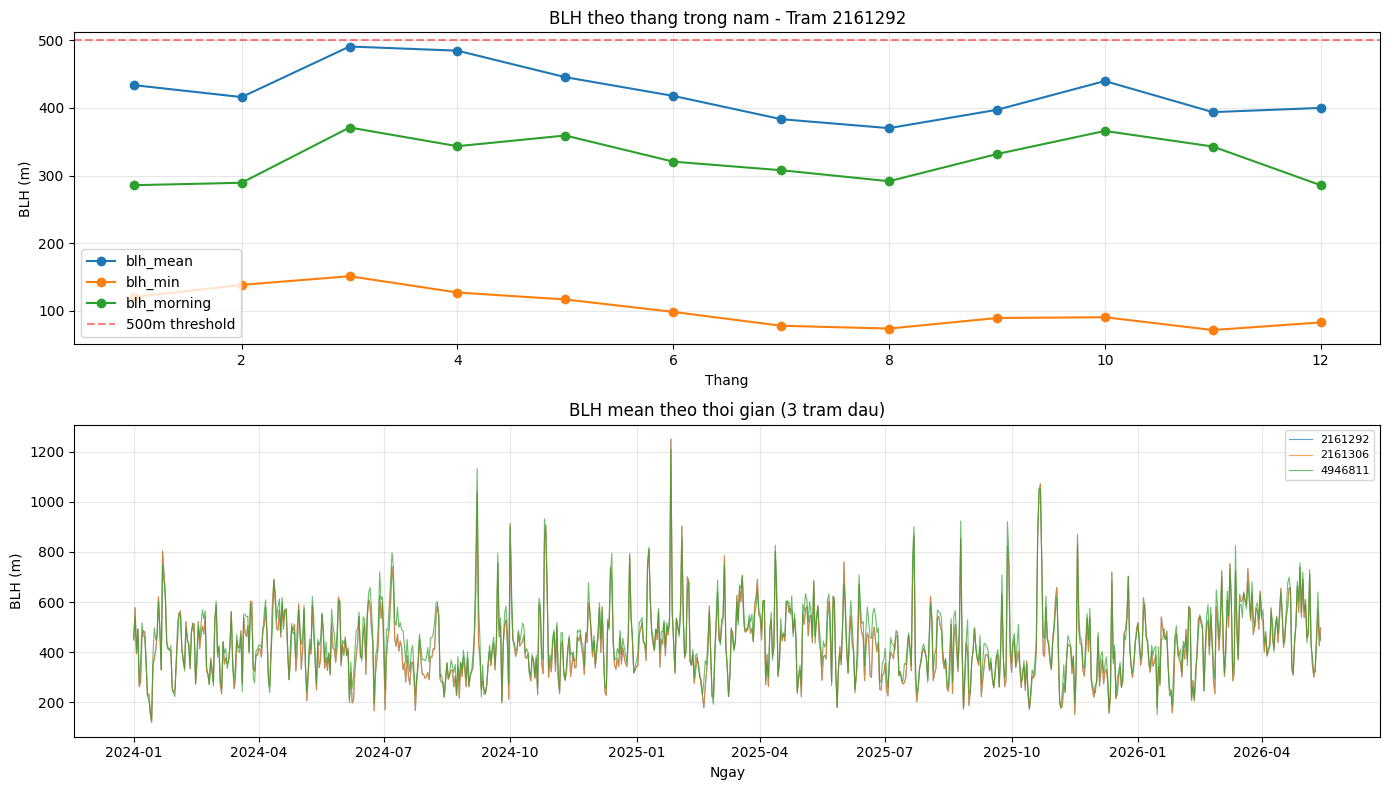


BLH mua dong (thang 11-2) thap -> o nhiem cao. BLH mua he cao -> khue tan tot.


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: BLH mean by month (seasonal pattern)
sample = blh_df[blh_df["location_id"] == 2161292].copy()
sample["month"] = sample["date"].dt.month
monthly = sample.groupby("month")[["blh_mean", "blh_min", "blh_morning"]].mean()
monthly.plot(ax=axes[0], marker="o")
axes[0].set_title("BLH theo thang trong nam - Tram 2161292", fontsize=12)
axes[0].set_xlabel("Thang"); axes[0].set_ylabel("BLH (m)")
axes[0].axhline(500, color="red", ls="--", alpha=0.5, label="500m threshold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Time series BLH mean
for loc_id in list(STATIONS.keys())[:3]:
    sub = blh_df[blh_df["location_id"] == loc_id]
    axes[1].plot(sub["date"], sub["blh_mean"], alpha=0.7, linewidth=0.8, label=str(loc_id))
axes[1].set_title("BLH mean theo thoi gian (3 tram dau)", fontsize=12)
axes[1].set_xlabel("Ngay"); axes[1].set_ylabel("BLH (m)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / "outputs/era5_blh_seasonal.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nBLH mua dong (thang 11-2) thap -> o nhiem cao. BLH mua he cao -> khue tan tot.")

## Cell 8 — Lưu era5_blh_daily.csv

In [8]:
blh_df.to_csv(OUT_CSV, index=False)
print(f"Saved: {OUT_CSV}")
print(f"Shape: {blh_df.shape}")
print()
print(blh_df[["blh_mean", "blh_min", "blh_morning"]].describe().round(0))

Saved: D:\Bussiness_plan\Multimodal_PM25\data\processed\era5_blh_daily.csv
Shape: (5190, 6)

       blh_mean  blh_min  blh_morning
count    5190.0   5190.0       5190.0
mean      435.0    115.0        333.0
std       141.0    121.0        183.0
min       119.0     11.0         29.0
25%       338.0     31.0        212.0
50%       421.0     72.0        287.0
75%       512.0    157.0        411.0
max      1250.0    891.0       1246.0


## Cell 9 — Merge vào daily_merged.csv

In [9]:
# Load main data
main = pd.read_csv(MERGED, parse_dates=["date"])
print(f"daily_merged.csv: {main.shape}")
print(f"Columns truoc merge: {list(main.columns[-5:])}")

# Remove old BLH columns if re-running
for col in ["blh_mean", "blh_min", "blh_morning", "blh_max"]:
    if col in main.columns:
        main.drop(columns=[col], inplace=True)

blh_df["date"] = pd.to_datetime(blh_df["date"])
main = main.merge(
    blh_df[["location_id", "date", "blh_mean", "blh_min", "blh_morning"]],
    on=["location_id", "date"],
    how="left",
)

# Fill gaps (ERA5 reanalysis nen hiem khi co gap)
for col in ["blh_mean", "blh_min", "blh_morning"]:
    main[col] = (
        main.sort_values(["location_id", "date"])
        .groupby("location_id")[col]
        .transform(lambda s: s.interpolate(method="linear", limit=3, limit_direction="both"))
    )

# Check coverage
for col in ["blh_mean", "blh_min", "blh_morning"]:
    pct = main[col].notna().mean() * 100
    print(f"  {col}: {pct:.1f}% coverage")

main.to_csv(MERGED, index=False)
print(f"\nUpdated: {MERGED}")
print(f"Shape sau merge: {main.shape}")
print(f"New columns: {[c for c in main.columns if 'blh' in c]}")

daily_merged.csv: (2566, 102)
Columns truoc merge: ['pm25_lag7', 'pm25_delta', 'pm25_roll3', 'pm25_roll7', 'pm25_roll7std']
  blh_mean: 100.0% coverage
  blh_min: 100.0% coverage
  blh_morning: 100.0% coverage



Updated: D:\Bussiness_plan\Multimodal_PM25\data\processed\daily_merged.csv
Shape sau merge: (2566, 101)
New columns: ['blh_mean', 'blh_min', 'blh_morning']


## Cell 10 — Kiểm tra correlation BLH vs PM2.5

Correlation with PM2.5:
blh_mean      -0.179
blh_min       -0.266
blh_morning   -0.344
Name: pm25, dtype: float64


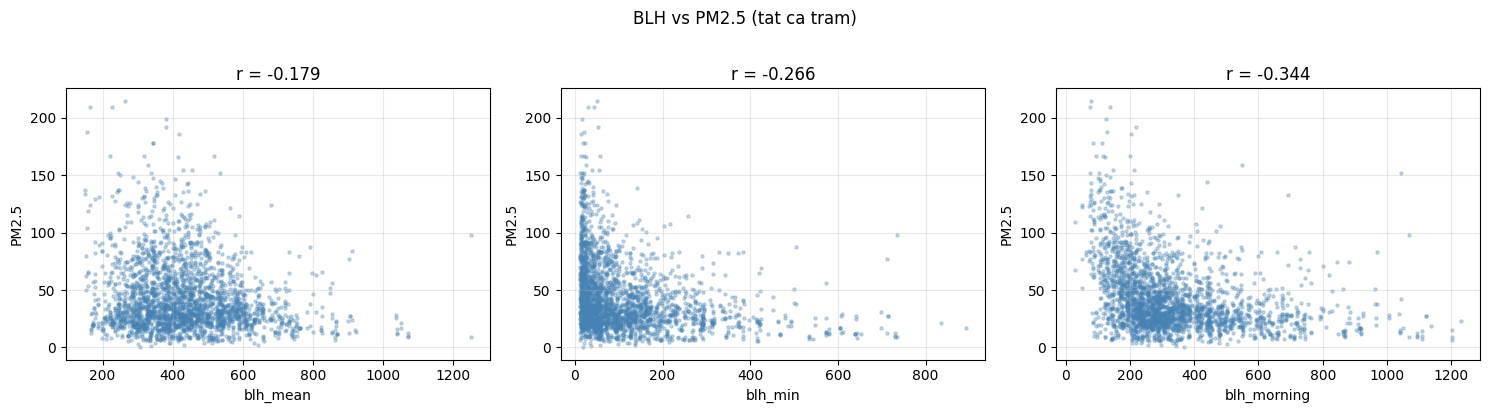


Ky vong: BLH va PM2.5 co tuong quan am (r ~ -0.3 den -0.5)
BLH thap mua dong -> PM2.5 cao.


In [10]:
import matplotlib.pyplot as plt

main = pd.read_csv(MERGED, parse_dates=["date"])

# Correlation
cols_of_interest = ["pm25", "blh_mean", "blh_min", "blh_morning"]
corr = main[cols_of_interest].corr()
print("Correlation with PM2.5:")
print(corr["pm25"].drop("pm25").round(3))

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["blh_mean", "blh_min", "blh_morning"]):
    sub = main[["pm25", col]].dropna()
    ax.scatter(sub[col], sub["pm25"], alpha=0.3, s=5, color="steelblue")
    r = sub.corr().iloc[0, 1]
    ax.set_xlabel(col); ax.set_ylabel("PM2.5")
    ax.set_title(f"r = {r:.3f}")
    ax.grid(alpha=0.3)

plt.suptitle("BLH vs PM2.5 (tat ca tram)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(ROOT / "outputs/era5_blh_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nKy vong: BLH va PM2.5 co tuong quan am (r ~ -0.3 den -0.5)")
print("BLH thap mua dong -> PM2.5 cao.")

## Cell 11 — Hướng dẫn tích hợp vào train_3d_v2.py

Sau khi chạy xong notebook này, thêm BLH vào model:

```python
# Trong train_3d_v2.py — phần ctx_feats
ctx_feats = [
    # ... các feature hiện tại ...
    "blh_mean",      # BLH 24h mean
    "blh_min",       # BLH minimum (worst stagnation)
    "blh_morning",   # morning rush hour BLH
]

# Thêm vào tab_cols cho XGBoost/LightGBM
tab_cols = [
    # ... các feature hiện tại ...
    "blh_mean", "blh_min", "blh_morning",
]
```

**Dự đoán cải thiện:** +2–4% R² (từ 0.71 → 0.73–0.75) do BLH capture được seasonal pattern mùa đông.